In [141]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [142]:
df = pd.read_csv('data/flight_data_2024_sample.csv')

In [143]:
df.head(10) 

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,1018,1015.0,-3.0,21.0,1036.0,1135.0,4.0,1149,1139.0,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,1637,1633.0,-4.0,14.0,1647.0,1900.0,6.0,1923,1906.0,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,1000,952.0,-8.0,13.0,1005.0,1034.0,8.0,1059,1042.0,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,1330,1334.0,4.0,8.0,1342.0,1425.0,6.0,1430,1431.0,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,1340,1333.0,-7.0,16.0,1349.0,1505.0,4.0,1510,1509.0,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0
5,2024,4,15,1,2024-04-15,WN,2358.0,SAN,"San Diego, CA",California,PHX,"Phoenix, AZ",Arizona,715,708.0,-7.0,13.0,721.0,812.0,4.0,830,816.0,-14.0,0,NaN,0,75.0,68.0,51.0,304.0,0,0,0,0,0
6,2024,11,27,3,2024-11-27,G4,163.0,MLB,"Melbourne, FL",Florida,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,933,924.0,-9.0,12.0,936.0,1153.0,5.0,1202,1158.0,-4.0,0,NaN,0,149.0,154.0,137.0,914.0,0,0,0,0,0
7,2024,8,31,6,2024-08-31,AS,1269.0,BNA,"Nashville, TN",Tennessee,PDX,"Portland, OR",Oregon,1855,1850.0,-5.0,21.0,1911.0,2125.0,3.0,2155,2128.0,-27.0,0,NaN,0,300.0,278.0,254.0,1973.0,0,0,0,0,0
8,2024,4,19,5,2024-04-19,OO,3438.0,LAX,"Los Angeles, CA",California,SJC,"San Jose, CA",California,820,814.0,-6.0,29.0,843.0,932.0,5.0,939,937.0,-2.0,0,NaN,0,79.0,83.0,49.0,308.0,0,0,0,0,0
9,2024,2,8,4,2024-02-08,OO,5654.0,SFO,"San Francisco, CA",California,BFL,"Bakersfield, CA",California,2235,2227.0,-8.0,17.0,2244.0,2324.0,3.0,2350,2327.0,-23.0,0,NaN,0,75.0,60.0,40.0,238.0,0,0,0,0,0


In [144]:

# 2. Dizionario completo per tradurre TUTTE le 35 colonne
traduzione_totale = {
    'year': 'anno',
    'month': 'mese',
    'day_of_month': 'giorno_mese',
    'day_of_week': 'giorno_settimana',
    'fl_date': 'data_volo',
    'op_unique_carrier': 'compagnia',
    'op_carrier_fl_num': 'num_volo',
    'origin': 'aeroporto_orig_cod',
    'origin_city_name': 'citta_orig',
    'origin_state_nm': 'stato_orig',
    'dest': 'aeroporto_dest_cod',
    'dest_city_name': 'citta_dest',
    'dest_state_nm': 'stato_dest',
    'crs_dep_time': 'ora_part_prevista',
    'dep_time': 'ora_part_reale',
    'dep_delay': 'ritardo_partenza',
    'taxi_out': 'tempo_rullaggio_uscita',
    'wheels_off': 'ora_decollo',
    'wheels_on': 'ora_atterraggio',
    'taxi_in': 'tempo_rullaggio_entrata',
    'crs_arr_time': 'ora_arr_prevista',
    'arr_time': 'ora_arr_reale',
    'arr_delay': 'ritardo_arrivo',
    'cancelled': 'cancellato',
    'cancellation_code': 'codice_cancellazione',
    'diverted': 'dirottato',
    'crs_elapsed_time': 'durata_prevista',
    'actual_elapsed_time': 'durata_reale',
    'air_time': 'minuti_volo_effettivi',
    'distance': 'distanza',
    'carrier_delay': 'ritardo_vettore',
    'weather_delay': 'ritardo_meteo',
    'nas_delay': 'ritardo_traffico_aereo',
    'security_delay': 'ritardo_sicurezza',
    'late_aircraft_delay': 'ritardo_aereo_precedente'
}

# 3. Applicazione della traduzione
df.rename(columns=traduzione_totale, inplace=True)

# 4. Visualizzazione delle prime 10 righe
df.head(10)

,anno,mese,giorno_mese,giorno_settimana,data_volo,compagnia,num_volo,aeroporto_orig_cod,citta_orig,stato_orig,aeroporto_dest_cod,citta_dest,stato_dest,ora_part_prevista,ora_part_reale,ritardo_partenza,tempo_rullaggio_uscita,ora_decollo,ora_atterraggio,tempo_rullaggio_entrata,ora_arr_prevista,ora_arr_reale,ritardo_arrivo,cancellato,codice_cancellazione,dirottato,durata_prevista,durata_reale,minuti_volo_effettivi,distanza,ritardo_vettore,ritardo_meteo,ritardo_traffico_aereo,ritardo_sicurezza,ritardo_aereo_precedente
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,RAP,"Rapid City, SD",South Dakota,1018,1015.0,-3.0,21.0,1036.0,1135.0,4.0,1149,1139.0,-10.0,0,NaN,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,PHX,"Phoenix, AZ",Arizona,1637,1633.0,-4.0,14.0,1647.0,1900.0,6.0,1923,1906.0,-17.0,0,NaN,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,ATL,"Atlanta, GA",Georgia,1000,952.0,-8.0,13.0,1005.0,1034.0,8.0,1059,1042.0,-17.0,0,NaN,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,LAS,"Las Vegas, NV",Nevada,1330,1334.0,4.0,8.0,1342.0,1425.0,6.0,1430,1431.0,1.0,0,NaN,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,MYR,"Myrtle Beach, SC",South Carolina,1340,1333.0,-7.0,16.0,1349.0,1505.0,4.0,1510,1509.0,-1.0,0,NaN,0,90.0,96.0,76.0,399.0,0,0,0,0,0
5,2024,4,15,1,2024-04-15,WN,2358.0,SAN,"San Diego, CA",California,PHX,"Phoenix, AZ",Arizona,715,708.0,-7.0,13.0,721.0,812.0,4.0,830,816.0,-14.0,0,NaN,0,75.0,68.0,51.0,304.0,0,0,0,0,0
6,2024,11,27,3,2024-11-27,G4,163.0,MLB,"Melbourne, FL",Florida,ABE,"Allentown/Bethlehem/Easton, PA",Pennsylvania,933,924.0,-9.0,12.0,936.0,1153.0,5.0,1202,1158.0,-4.0,0,NaN,0,149.0,154.0,137.0,914.0,0,0,0,0,0
7,2024,8,31,6,2024-08-31,AS,1269.0,BNA,"Nashville, TN",Tennessee,PDX,"Portland, OR",Oregon,1855,1850.0,-5.0,21.0,1911.0,2125.0,3.0,2155,2128.0,-27.0,0,NaN,0,300.0,278.0,254.0,1973.0,0,0,0,0,0
8,2024,4,19,5,2024-04-19,OO,3438.0,LAX,"Los Angeles, CA",California,SJC,"San Jose, CA",California,820,814.0,-6.0,29.0,843.0,932.0,5.0,939,937.0,-2.0,0,NaN,0,79.0,83.0,49.0,308.0,0,0,0,0,0
9,2024,2,8,4,2024-02-08,OO,5654.0,SFO,"San Francisco, CA",California,BFL,"Bakersfield, CA",California,2235,2227.0,-8.0,17.0,2244.0,2324.0,3.0,2350,2327.0,-23.0,0,NaN,0,75.0,60.0,40.0,238.0,0,0,0,0,0


In [145]:
# 1. Vediamo quanti voli sono stati cancellati o dirottati
cancellati = df['cancellato'].sum()
dirottati = df['dirottato'].sum()

# 2. Vediamo quante celle sono completamente vuote (NaN) per ogni colonna
valori_nulli = df.isnull().sum()

# 3. Stampiamo un report per decidere
print("--- REPORT DIAGNOSTICO ---")
print(f"Voli totali nel file: {len(df)}")
print(f"Voli cancellati: {cancellati}")
print(f"Voli dirottati: {dirottati}")
print("\nConteggio valori nulli per colonna (le più critiche):")
print(valori_nulli[valori_nulli > 0]) # Mostra solo le colonne che hanno almeno un errore

--- REPORT DIAGNOSTICO ---
Voli totali nel file: 10000
Voli cancellati: 122
Voli dirottati: 42

Conteggio valori nulli per colonna (le più critiche):
ora_part_reale              116
ritardo_partenza            116
tempo_rullaggio_uscita      120
ora_decollo                 120
ora_atterraggio             127
tempo_rullaggio_entrata     127
ora_arr_reale               127
ritardo_arrivo              164
codice_cancellazione       9878
durata_reale                164
minuti_volo_effettivi       164
dtype: int64


In [146]:
print(f"Righe prima: {len(df)}")

df = df[(df['cancellato'] == 0) & (df['dirottato'] == 0)].copy()

print(f"Righe dopo:  {len(df)}")
print(f"Rimossi:     {10000 - len(df)} voli (cancellati + dirottati)")

Righe prima: 10000
Righe dopo:  9836
Rimossi:     164 voli (cancellati + dirottati)


In [147]:
cols_da_buttare = [
    # zero varianza
    'anno',
    # ridondanti (il codice IATA contiene già l'info)
    'citta_orig', 'stato_orig', 'citta_dest', 'stato_dest',
    # non generalizza (identifica il singolo volo)
    'num_volo',
    # quasi tutto NaN (esiste solo per i cancellati, che abbiamo già rimosso)
    'codice_cancellazione',
    # non servono più dopo il filtro
    'cancellato', 'dirottato'
]

df.drop(columns=cols_da_buttare, inplace=True)

print(f"Colonne rimaste: {df.shape[1]}")
print(df.columns.tolist())

Colonne rimaste: 26
['mese', 'giorno_mese', 'giorno_settimana', 'data_volo', 'compagnia', 'aeroporto_orig_cod', 'aeroporto_dest_cod', 'ora_part_prevista', 'ora_part_reale', 'ritardo_partenza', 'tempo_rullaggio_uscita', 'ora_decollo', 'ora_atterraggio', 'tempo_rullaggio_entrata', 'ora_arr_prevista', 'ora_arr_reale', 'ritardo_arrivo', 'durata_prevista', 'durata_reale', 'minuti_volo_effettivi', 'distanza', 'ritardo_vettore', 'ritardo_meteo', 'ritardo_traffico_aereo', 'ritardo_sicurezza', 'ritardo_aereo_precedente']


In [148]:
# rotta: combina aeroporto di origine e destinazione
df['rotta'] = df['aeroporto_orig_cod'] + '-' + df['aeroporto_dest_cod']

# ora di partenza: da formato HHMM (es. 1547) estraiamo solo l'ora (15)
df['ora_partenza'] = df['ora_part_prevista'] // 100

# fascia oraria basata sull'ora di partenza
def fascia_oraria(ora):
    if 5 <= ora < 12:
        return 'mattina'
    elif 12 <= ora < 18:
        return 'pomeriggio'
    elif 18 <= ora < 22:
        return 'sera'
    else:
        return 'notte'

df['fascia_partenza'] = df['ora_partenza'].apply(fascia_oraria)

# verifica
print(df[['aeroporto_orig_cod', 'aeroporto_dest_cod', 'rotta', 'ora_part_prevista', 'ora_partenza', 'fascia_partenza']].head(10))

  aeroporto_orig_cod aeroporto_dest_cod    rotta  ora_part_prevista  \
0                DFW                RAP  DFW-RAP               1018   
1                CLT                PHX  CLT-PHX               1637   
2                CHA                ATL  CHA-ATL               1000   
3                OMA                LAS  OMA-LAS               1330   
4                BWI                MYR  BWI-MYR               1340   
5                SAN                PHX  SAN-PHX                715   
6                MLB                ABE  MLB-ABE                933   
7                BNA                PDX  BNA-PDX               1855   
8                LAX                SJC  LAX-SJC                820   
9                SFO                BFL  SFO-BFL               2235   

   ora_partenza fascia_partenza  
0            10         mattina  
1            16      pomeriggio  
2            10         mattina  
3            13      pomeriggio  
4            13      pomeriggio  
5             

In [149]:
# media ritardo meteo per aeroporto di origine
df['media_meteo_orig'] = df.groupby('aeroporto_orig_cod')['ritardo_meteo'].transform('mean')

# media ritardo vettore per compagnia
df['media_ritardo_compagnia'] = df.groupby('compagnia')['ritardo_vettore'].transform('mean')

# media ritardo traffico per aeroporto di origine
df['media_traffico_orig'] = df.groupby('aeroporto_orig_cod')['ritardo_traffico_aereo'].transform('mean')

# media ritardo sicurezza per aeroporto di origine
df['media_sicurezza_orig'] = df.groupby('aeroporto_orig_cod')['ritardo_sicurezza'].transform('mean')

# media ritardo aereo precedente per compagnia e fascia oraria
df['media_ritardo_prec'] = df.groupby(['compagnia', 'fascia_partenza'])['ritardo_aereo_precedente'].transform('mean')

# media durata volo per rotta
df['media_durata_rotta'] = df.groupby('rotta')['minuti_volo_effettivi'].transform('mean')

# verifica
print(df[['media_meteo_orig', 'media_ritardo_compagnia', 'media_traffico_orig',
          'media_sicurezza_orig', 'media_ritardo_prec', 'media_durata_rotta']].head(10))

   media_meteo_orig  media_ritardo_compagnia  media_traffico_orig  \
0          2.626168                 2.929825             2.546729   
1          0.952229                 6.933824             3.162420   
2          7.133333                 5.632353             2.800000   
3          1.100000                 3.178123             6.600000   
4          0.014815                 3.178123             1.925926   
5          0.105634                 3.178123             3.401408   
6          0.000000                 5.817647             0.000000   
7          0.153846                 2.584127             4.814103   
8          0.312950                 7.815370             2.751799   
9          3.967568                 7.815370             2.362162   

   media_sicurezza_orig  media_ritardo_prec  media_durata_rotta  
0                   0.0            4.393333          117.666667  
1                   0.0           14.450226          244.142857  
2                   0.0            3.44444

In [150]:
# Creiamo il target (0 o 1)
df['in_ritardo'] = (df['ritardo_arrivo'] > 15).astype(int)

print(f"Target creato! Voli in ritardo: {df['in_ritardo'].sum()}")

Target creato! Voli in ritardo: 2040


In [151]:
# Lista delle colonne "del futuro" o non più utili
cols_da_eliminare = [
    'ritardo_partenza', 'ritardo_arrivo', 'ritardo_vettore', 'ritardo_meteo', 
    'ritardo_traffico_aereo', 'ritardo_sicurezza', 'ritardo_aereo_precedente',
    'ora_part_reale', 'ora_arr_reale', 'durata_reale', 'minuti_volo_effettivi',
    'ora_decollo', 'ora_atterraggio', 'tempo_rullaggio_uscita', 'tempo_rullaggio_entrata'
]

df.drop(columns=cols_da_eliminare, inplace=True)

print(f"Pulizia completata. Colonne rimaste per il modello: {len(df.columns)}")
df.head(10)


Pulizia completata. Colonne rimaste per il modello: 21


,mese,giorno_mese,giorno_settimana,data_volo,compagnia,aeroporto_orig_cod,aeroporto_dest_cod,ora_part_prevista,ora_arr_prevista,durata_prevista,distanza,rotta,ora_partenza,fascia_partenza,media_meteo_orig,media_ritardo_compagnia,media_traffico_orig,media_sicurezza_orig,media_ritardo_prec,media_durata_rotta,in_ritardo
0,4,18,4,2024-04-18,MQ,DFW,RAP,1018,1149,151.0,835.0,DFW-RAP,10,mattina,2.626168,2.929825,2.546729,0.0,4.393333,117.666667,0
1,1,1,1,2024-01-01,AA,CLT,PHX,1637,1923,286.0,1773.0,CLT-PHX,16,pomeriggio,0.952229,6.933824,3.162420,0.0,14.450226,244.142857,0
2,12,12,4,2024-12-12,9E,CHA,ATL,1000,1059,59.0,106.0,CHA-ATL,10,mattina,7.133333,5.632353,2.800000,0.0,3.444444,28.142857,0
3,4,8,1,2024-04-08,WN,OMA,LAS,1330,1430,180.0,1099.0,OMA-LAS,13,pomeriggio,1.100000,3.178123,6.600000,0.0,7.244356,158.000000,0
4,2,16,5,2024-02-16,WN,BWI,MYR,1340,1510,90.0,399.0,BWI-MYR,13,pomeriggio,0.014815,3.178123,1.925926,0.0,7.244356,69.500000,0
5,4,15,1,2024-04-15,WN,SAN,PHX,715,830,75.0,304.0,SAN-PHX,7,mattina,0.105634,3.178123,3.401408,0.0,1.659781,52.285714,0
6,11,27,3,2024-11-27,G4,MLB,ABE,933,1202,149.0,914.0,MLB-ABE,9,mattina,0.000000,5.817647,0.000000,0.0,0.750000,137.000000,0
7,8,31,6,2024-08-31,AS,BNA,PDX,1855,2155,300.0,1973.0,BNA-PDX,18,sera,0.153846,2.584127,4.814103,0.0,7.253968,262.500000,0
8,4,19,5,2024-04-19,OO,LAX,SJC,820,939,79.0,308.0,LAX-SJC,8,mattina,0.312950,7.815370,2.751799,0.0,1.803922,48.714286,0
9,2,8,4,2024-02-08,OO,SFO,BFL,2235,2350,75.0,238.0,SFO-BFL,22,notte,3.967568,7.815370,2.362162,0.0,0.000000,40.000000,0


In [152]:
# Lista delle colonne da rimuovere per evitare ridondanza
cols_da_rimuovere = [
    'aeroporto_orig_cod', 
    'aeroporto_dest_cod', 
    'ora_part_prevista', 
    'ora_arr_prevista', 
    'ora_partenza',
    'data_volo'
]

# Eseguiamo la rimozione
df.drop(columns=cols_da_rimuovere, inplace=True)

print(f"Colonne rimaste ({len(df.columns)}): {df.columns.tolist()}")
df.head(10)

Colonne rimaste (15): ['mese', 'giorno_mese', 'giorno_settimana', 'compagnia', 'durata_prevista', 'distanza', 'rotta', 'fascia_partenza', 'media_meteo_orig', 'media_ritardo_compagnia', 'media_traffico_orig', 'media_sicurezza_orig', 'media_ritardo_prec', 'media_durata_rotta', 'in_ritardo']


,mese,giorno_mese,giorno_settimana,compagnia,durata_prevista,distanza,rotta,fascia_partenza,media_meteo_orig,media_ritardo_compagnia,media_traffico_orig,media_sicurezza_orig,media_ritardo_prec,media_durata_rotta,in_ritardo
0,4,18,4,MQ,151.0,835.0,DFW-RAP,mattina,2.626168,2.929825,2.546729,0.0,4.393333,117.666667,0
1,1,1,1,AA,286.0,1773.0,CLT-PHX,pomeriggio,0.952229,6.933824,3.162420,0.0,14.450226,244.142857,0
2,12,12,4,9E,59.0,106.0,CHA-ATL,mattina,7.133333,5.632353,2.800000,0.0,3.444444,28.142857,0
3,4,8,1,WN,180.0,1099.0,OMA-LAS,pomeriggio,1.100000,3.178123,6.600000,0.0,7.244356,158.000000,0
4,2,16,5,WN,90.0,399.0,BWI-MYR,pomeriggio,0.014815,3.178123,1.925926,0.0,7.244356,69.500000,0
5,4,15,1,WN,75.0,304.0,SAN-PHX,mattina,0.105634,3.178123,3.401408,0.0,1.659781,52.285714,0
6,11,27,3,G4,149.0,914.0,MLB-ABE,mattina,0.000000,5.817647,0.000000,0.0,0.750000,137.000000,0
7,8,31,6,AS,300.0,1973.0,BNA-PDX,sera,0.153846,2.584127,4.814103,0.0,7.253968,262.500000,0
8,4,19,5,OO,79.0,308.0,LAX-SJC,mattina,0.312950,7.815370,2.751799,0.0,1.803922,48.714286,0
9,2,8,4,OO,75.0,238.0,SFO-BFL,notte,3.967568,7.815370,2.362162,0.0,0.000000,40.000000,0


In [153]:
# Analizziamo tutte le medie storiche rispetto al target
analisi_medie = df.groupby('in_ritardo')[[
    'media_meteo_orig', 
    'media_ritardo_compagnia', 
    'media_traffico_orig', 
    'media_sicurezza_orig', 
    'media_ritardo_prec', 
    'media_durata_rotta'
]].mean()

print(analisi_medie)

            media_meteo_orig  media_ritardo_compagnia  media_traffico_orig  \
in_ritardo                                                                   
0                   1.038468                 4.904872             2.987406   
1                   1.340739                 5.132656             3.422150   

            media_sicurezza_orig  media_ritardo_prec  media_durata_rotta  
in_ritardo                                                                
0                       0.008703            5.826561          114.463524  
1                       0.009879            7.842220          119.198218  


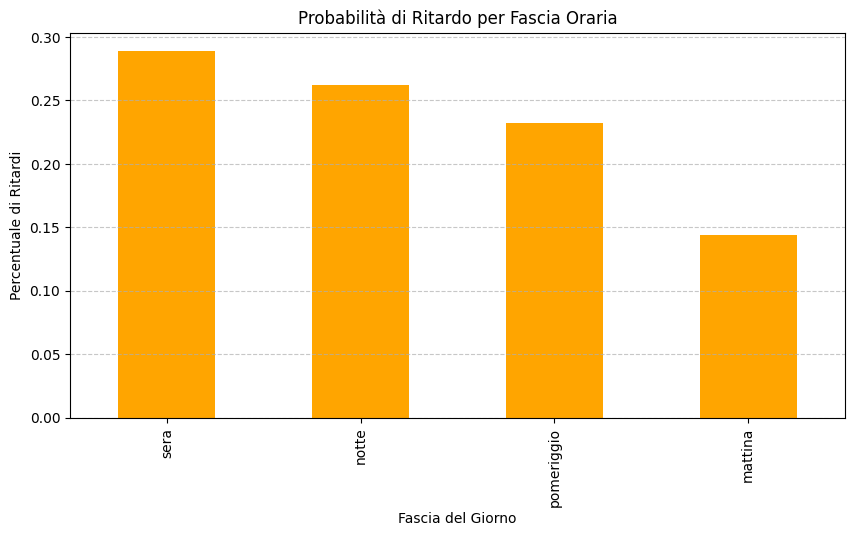

Percentuali esatte:
fascia_partenza
sera          0.288984
notte         0.261830
pomeriggio    0.231844
mattina       0.143842
Name: in_ritardo, dtype: float64


In [154]:
import matplotlib.pyplot as plt

# Calcoliamo la percentuale di ritardi (media della colonna 0/1) per ogni fascia
ritardo_fascia = df.groupby('fascia_partenza')['in_ritardo'].mean().sort_values(ascending=False)

# Creiamo il grafico
plt.figure(figsize=(10, 5))
ritardo_fascia.plot(kind='bar', color='orange')
plt.title('Probabilità di Ritardo per Fascia Oraria')
plt.ylabel('Percentuale di Ritardi')
plt.xlabel('Fascia del Giorno')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Percentuali esatte:")
print(ritardo_fascia)

In [155]:
# 1. Calcoliamo il numero di voli e il tasso di ritardo per ogni compagnia
stats_compagnia = df.groupby('compagnia').agg(
    numero_voli=('in_ritardo', 'count'),
    tasso_ritardo=('in_ritardo', 'mean')
).sort_values(by='tasso_ritardo', ascending=False)

# 2. Visualizziamo le prime righe
print("Statistiche per Compagnia (ordinate per tasso di ritardo):")
print(stats_compagnia.head(10))


Statistiche per Compagnia (ordinate per tasso di ritardo):
           numero_voli  tasso_ritardo
compagnia                            
F9                 288       0.291667
G4                 170       0.276471
AA                1360       0.272059
B6                 328       0.259146
OH                 316       0.246835
NK                 350       0.228571
UA                1015       0.214778
WN                1993       0.205218
AS                 315       0.196825
OO                1067       0.191190


In [156]:
# Trasformiamo le colonne di testo in numeri
df['compagnia_n'] = pd.factorize(df['compagnia'])[0]
df['rotta_n'] = pd.factorize(df['rotta'])[0]
df['fascia_n'] = pd.factorize(df['fascia_partenza'])[0]

# Ora possiamo eliminare le colonne di testo originali
df.drop(columns=['compagnia', 'rotta', 'fascia_partenza'], inplace=True)

df.head()

,mese,giorno_mese,giorno_settimana,durata_prevista,distanza,media_meteo_orig,media_ritardo_compagnia,media_traffico_orig,media_sicurezza_orig,media_ritardo_prec,media_durata_rotta,in_ritardo,compagnia_n,rotta_n,fascia_n
0,4,18,4,151.0,835.0,2.626168,2.929825,2.546729,0.0,4.393333,117.666667,0,0,0,0
1,1,1,1,286.0,1773.0,0.952229,6.933824,3.162420,0.0,14.450226,244.142857,0,1,1,1
2,12,12,4,59.0,106.0,7.133333,5.632353,2.800000,0.0,3.444444,28.142857,0,2,2,0
3,4,8,1,180.0,1099.0,1.100000,3.178123,6.600000,0.0,7.244356,158.000000,0,3,3,1
4,2,16,5,90.0,399.0,0.014815,3.178123,1.925926,0.0,7.244356,69.500000,0,3,4,1
